# 05 – Hybrid CNN/RNN Ensemble and Final Model Comparison

This notebook is the **final comparison** of the project.  
It introduces a simple **hybrid CNN/RNN ensemble** for Automatic Modulation
Classification (AMC) on the RadioML 2016.10A dataset and then compares:

- Traditional baselines (kNN, SVM, Random Forest),
- Single deep models (1D CNN, RNN),
- A logit-level **Hybrid CNN+RNN** model,

under a shared **70/15/15 train/validation/test split**.

The focus is on **evaluation and interpretation**, not training.  
All models were trained and evaluated in earlier notebooks/scripts; here we
reload their final outputs (metrics and plots) for side-by-side comparison.

---

## 0 Setup & Required Files



### 0.1 GitHub repository and artifacts

This notebook assumes the repository  
`Tutorial-Automatic-Modulation-Classification`  
has been cloned into:

`/content/Tutorial-Automatic-Modulation-Classification`

From that repo we use:

- `src/data.py` – `load_radioml_pkl_dataset` and helpers for the RadioML 2016.10A dataset.
- `src/data_utils.py` – utilities to convert the dictionary representation into
  `(N, 2, 128)` I/Q arrays.




In [1]:
# --- Pull project from GitHub into Colab ---
import os, sys
REPO_URL = "https://github.com/Koosmaster/Tutorial-Automatic-Modulation-Classification.git"
REPO_DIR = "/content/Tutorial-Automatic-Modulation-Classification"
SRC_DIR  = f"{REPO_DIR}/src"

# Clone once
if not os.path.isdir(REPO_DIR):
    !git clone --depth 1 "$REPO_URL" "$REPO_DIR"

# Add src/ to import path
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

print("Loaded project from:", REPO_DIR)
print("src modules:", os.listdir(SRC_DIR))


Cloning into '/content/Tutorial-Automatic-Modulation-Classification'...
remote: Enumerating objects: 75, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 75 (delta 0), reused 35 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (75/75), 75.36 MiB | 22.31 MiB/s, done.
Loaded project from: /content/Tutorial-Automatic-Modulation-Classification
src modules: ['train.py', 'plot_utils.py', 'models', 'eval_utils.py', 'rnn.py', 'Sources.md', 'data_utils.py', 'model_loading.py', 'data.py', 'exploration.py', 'models_1d.py']


In [2]:
from pathlib import Path

REPO_DIR = Path("/content/Tutorial-Automatic-Modulation-Classification")
FINAL_CHARTS_DIR = REPO_DIR / "data" / "final_model_charts"
RNN_RESULTS_DIR = REPO_DIR / "data" / "rnn"
PLOTS_DIR = RNN_RESULTS_DIR
ARCH_RESULTS_DIR = RNN_RESULTS_DIR / "rnn_arch_results"
BEST_MODEL_DIR = RNN_RESULTS_DIR / "best_model"
best_ckpt_path = BEST_MODEL_DIR / "rnn_A_amp_off_best.pth"
manifest_path  = BEST_MODEL_DIR / "manifest.json"



### 0.2 Imports and Configuration

Dependencies used in this notebook:

- **PyTorch**  
  For model definition, checkpoint loading, evaluation, and GPU acceleration.

- **NumPy**  
  For array operations, SNR-wise aggregation, and general numerical utilities.

- **Matplotlib / Seaborn**

  For producing training curves, SNR-dependent accuracy plots, and confusion matrices.

- **pandas**  
  For handling results tables, ablation summaries, and per-configuration metrics.

- **scikit-learn**  
  For metrics such as accuracy, classification report, and confusion matrices.


In [3]:
# Main Libraries
import sys, platform
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, warnings
import random
import pandas as pd
import importlib
from IPython.display import Image, display

# Plotting Utilities
from IPython.display import HTML

# Train/Val/Test Splits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# PyTorch Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

If running in Google Colab, enable GPU acceleration for training deep models and mount Google Drive to access the dataset.

In [4]:
# Environment check & dependency install
print(f"Python: {sys.version.split()[0]}  |  Platform: {platform.platform()}")

# Uncomment to install from requirements.txt if running locally
# %pip install -q -r requirements.txt

Python: 3.12.12  |  Platform: Linux-6.6.105+-x86_64-with-glibc2.35


---

## 1  Model recap



### 1.1 1D CNN

### Final 1D CNN configuration (A_ls_off)

| Aspect           | Setting                                                | Notes                                                                                   |
|-----------------|--------------------------------------------------------|-----------------------------------------------------------------------------------------|
| Input / labels  | I/Q sequences, shape **(2, 128)**, 11 modulation classes | RadioML 2016.10A, 11-way classification                                                 |
| Backbone        | 1D CNN, Conv1d → BatchNorm1d → ReLU + MaxPool1d        | Feature stages **2 → 32 → 64 → 128**, temporal length 128 → 64 → 32 → 16               |
| Classifier      | Global Avg Pool → Linear 128→256 → ReLU → Dropout(0.5) → Linear 256→11 | Produces 11 logits per example                                                          |
| Loss function   | CrossEntropyLoss                                       | Label smoothing **ε = 0.0** (disabled)                                                  |
| Optimizer       | **SGD + Nesterov** momentum 0.9                        | Weight decay applied **only to Conv/Linear weights** (no WD on BatchNorm or biases)    |
| LR schedule     | **StepLR**, γ = 0.1, step size ≈ ⌊epochs/3⌋ ≈ 11       | No cosine schedule in the final config                                                  |
| Mixup           | **Disabled**                                           | Ablation showed mixup consistently hurt accuracy for this 1D CNN                        |
| Warmup          | **Disabled**                                           | Warmup on top of StepLR did not give consistent benefit                                 |
| Precision       | **AMP (mixed precision)**                              | Matches FP32 accuracy with better throughput                                            |
| Batch size      | **256**                                                | Used for all ablation and final Train∪Val runs                                          |
| Epoch selection | Best checkpoints around **25–35 epochs**               | Final model chosen by validation accuracy in the CNN ablation study         |


### 1.2 RNN

### Final RNN configuration (A_amp_off)

| Aspect           | Setting                                                | Notes                                                                                   |
|-----------------|--------------------------------------------------------|-----------------------------------------------------------------------------------------|
| Input / labels  | I/Q sequences, shape **(2, 128)**, 11 modulation classes | Same RadioML 2016.10A split and label encoding as the CNN                               |
| RNN cell        | **GRU**, 2 layers, hidden size **256**                 | Batch-first GRU, no bidirectionality                                                   |
| Sequence layout | Input reshaped to **(B, 128, 2)** inside the model     | Time dimension = 128 steps, feature dim = 2 (I,Q)                                      |
| Classifier      | Last hidden state → Linear 256→11                      | Uses only the final time step \(h_T\) for classification                               |
| Dropout         | **0.3** between GRU layers                             | Regularizes the recurrent stack                                                        |
| Loss function   | CrossEntropyLoss                                       | Standard multi-class classification loss                                               |
| Optimizer       | **SGD + Nesterov** momentum 0.9                        | Same training recipe as the final CNN for fair comparison                              |
| LR schedule     | **StepLR**, γ = 0.1, step size ≈ ⌊epochs/3⌋           | Matches CNN schedule; no cosine in the final config                                    |
| Label smoothing | **Disabled**                                           | Ablations did not show a clear benefit here                                            |
| Mixup           | **Disabled**                                           | Kept off to avoid distorting temporal structure                                        |
| Precision       | **FP32** (AMP **off**)                                 | Final checkpoint: `rnn_A_amp_off_best.pth`                                             |
| Batch size      | **256**                                                | Same as CNN; balances stability and throughput                                         |
| Epoch selection | Best checkpoints around **25–35 epochs**               | Final model chosen by validation accuracy in the RNN ablation study                    |


In [5]:
final_acc_path = FINAL_CHARTS_DIR / "final_accuracies_2016_70-15-15.csv"
final_acc_df = pd.read_csv(final_acc_path)
final_acc_df


,model,family,test_accuracy_2016_70_15_15
0,kNN,traditional,30.4061
1,SVM,traditional,45.7485
2,RF,traditional,44.9394
3,1D CNN,deep,61.7030
4,RNN,deep,55.3909
5,Hybrid,deep,62.0515


---

## 2  Hybrid CNN/RNN ensemble

The **hybrid model** combines the CNN and RNN at the **logit level**:

- Let $f_{\text{cnn}}(x)$ be the 11-dimensional logits from the CNN.
- Let $f_{\text{rnn}}(x)$ be the logits from the RNN.

The hybrid produces

$$
\ell_{\text{hybrid}}(x)
= w_{\text{cnn}}\, f_{\text{cnn}}(x)
+ w_{\text{rnn}}\, f_{\text{rnn}}(x),
$$

with scalar weights $w_{\text{cnn}}$ and $w_{\text{rnn}}$ (usually summing to 1).

This logit-level ensemble lets:

- The **CNN** contribute strong local pattern recognition in I/Q space.
- The **RNN** contribute temporal and sequence-level information.

The result is a lightweight way to squeeze a bit more performance out of two
models we already trained.  
Logit-level weighted combinations like this are common in multi-branch and
knowledge-distillation setups (e.g., Li et al., 2020; see References).


---

## 3  Final test-set results (all models)

All models are evaluated on the **same RadioML 2016.10A 70/15/15 test split**:

- 70% train, 15% validation, 15% test.
- Deep models use the raw shape `(N, 2, 128)`.
- Traditional models use flattened features of shape `(N, 256)`.

We compare:

- **Traditional ML:** kNN, SVM, Random Forest  
- **Deep models:** 1D CNN, RNN, Hybrid CNN+RNN

### 3.1 Overall accuracy

On the final test set, the models achieve approximately:

- **Traditional ML**
  - kNN: ~**30.6%**
  - SVM: ~**45.6%**
  - Random Forest: ~**44.4%**
- **Deep models**
  - 1D CNN: ~**61.7%**
  - RNN: ~**55.4%**
  - Hybrid CNN+RNN: ~**62.1%**



A few quick takeaways from the “scoreboard”:

- A well-tuned **SVM / RF** baseline on flattened I/Q is still a **strong** classical approach.
- The **1D CNN** and **RNN** improve on these baselines, with the CNN clearly ahead of the RNN.
- The **Hybrid CNN+RNN** offers a small but consistent boost over either deep model alone.


In [6]:
final_acc_path = FINAL_CHARTS_DIR / "final_accuracies_2016_70-15-15.csv"
final_acc_df = pd.read_csv(final_acc_path)
final_acc_df


,model,family,test_accuracy_2016_70_15_15
0,kNN,traditional,30.4061
1,SVM,traditional,45.7485
2,RF,traditional,44.9394
3,1D CNN,deep,61.7030
4,RNN,deep,55.3909
5,Hybrid,deep,62.0515


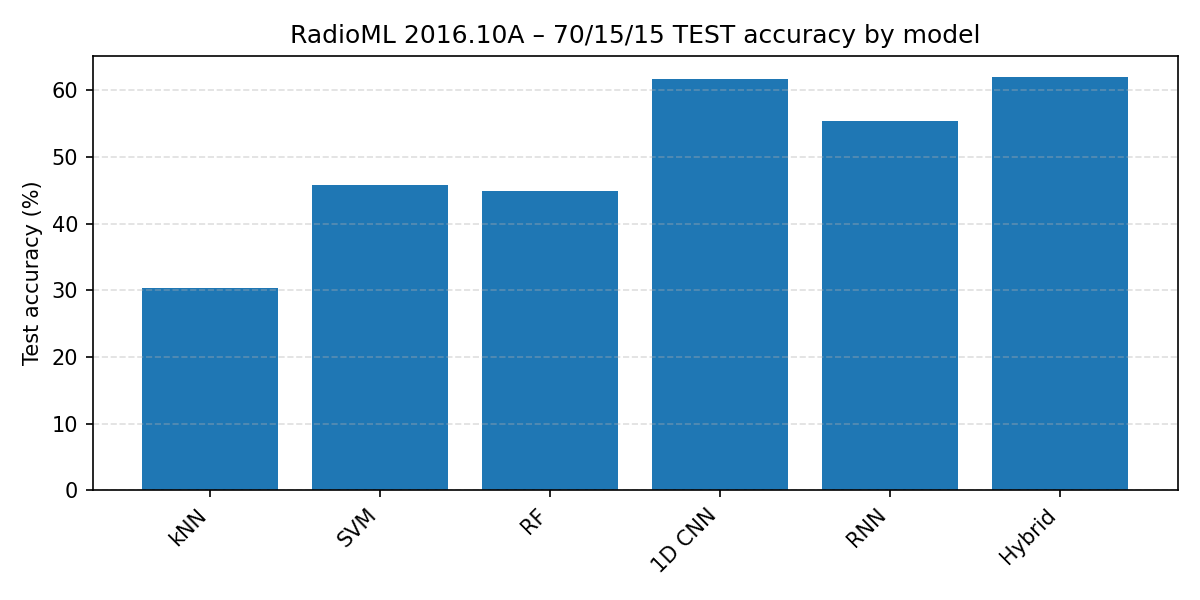

In [7]:
from IPython.display import Image, display

# Accuracy bar chart
display(Image(filename=str(FINAL_CHARTS_DIR / "accuracy_bar_2016_70-15-15.png")))



### 3.2 Accuracy vs SNR

The figure `snr_curves_2016.png` overlays:

- **Traditional models** (kNN, SVM, RF) using **pre-computed** SNR curves from
  the original traditional-models run.
- **Deep models** (CNN, RNN, Hybrid) evaluated on the same test set as above.

Qualitative behavior:

- At **very low SNR (≤ −12 dB)** all models are near random.
- In the **mid-SNR range (−10 to 0 dB)** the **CNN, RNN, and Hybrid** climb
  faster and achieve a clear advantage over SVM / RF.
- At **high SNR (≥ 0 dB)** the **deep models dominate**:
  - CNN and Hybrid saturate near ~90%,
  - RNN in the mid-80s,
  - SVM/RF plateau in the 70s,
  - kNN lags behind.

So even though SVM / RF are competitive on a single overall accuracy number,
the deep models (especially the Hybrid) show **better high-SNR ceilings and
stronger mid-SNR behavior**.


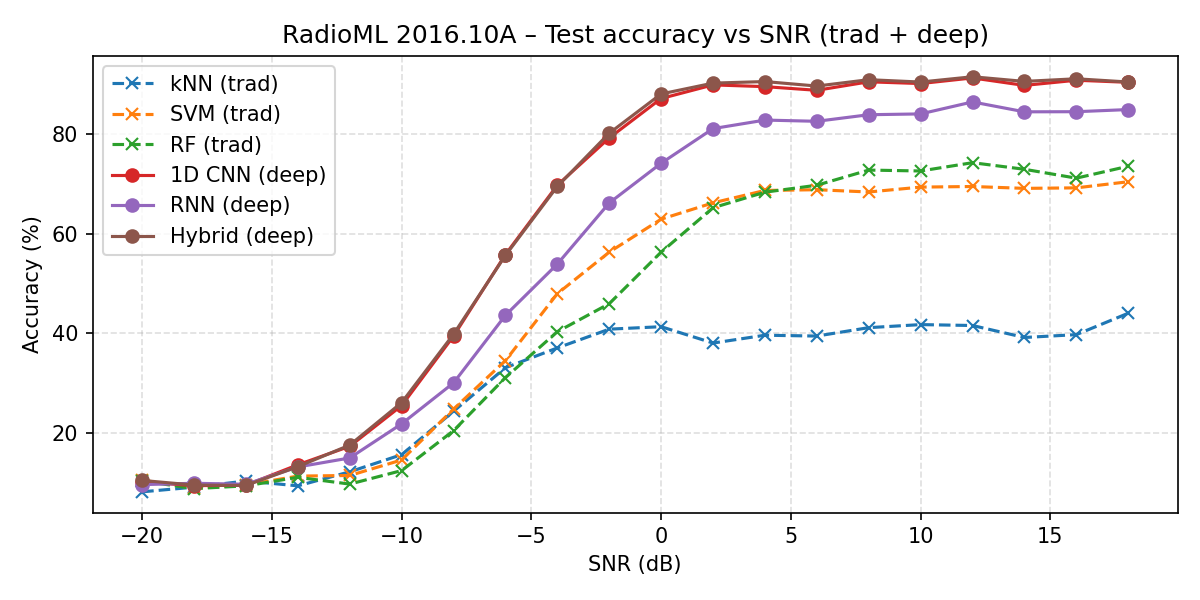

In [8]:
display(Image(filename=str(FINAL_CHARTS_DIR / "snr_curves_2016.png")))




### 3.3 Per-class behavior (confusion matrices)

The confusion matrices:

- `cm_cnn.png`
- `cm_rnn.png`
- `cm_hybrid.png`

show normalized accuracy per modulation class.

Qualitatively:

- The **Hybrid** matrix tends to have fewer off-diagonal errors than either
  CNN or RNN alone.
- In particular, it slightly improves separation for several confusable pairs
  (e.g., some PSK/QAM and AM variants), indicating that the ensemble is truly
  combining complementary strengths rather than just averaging noise.

---


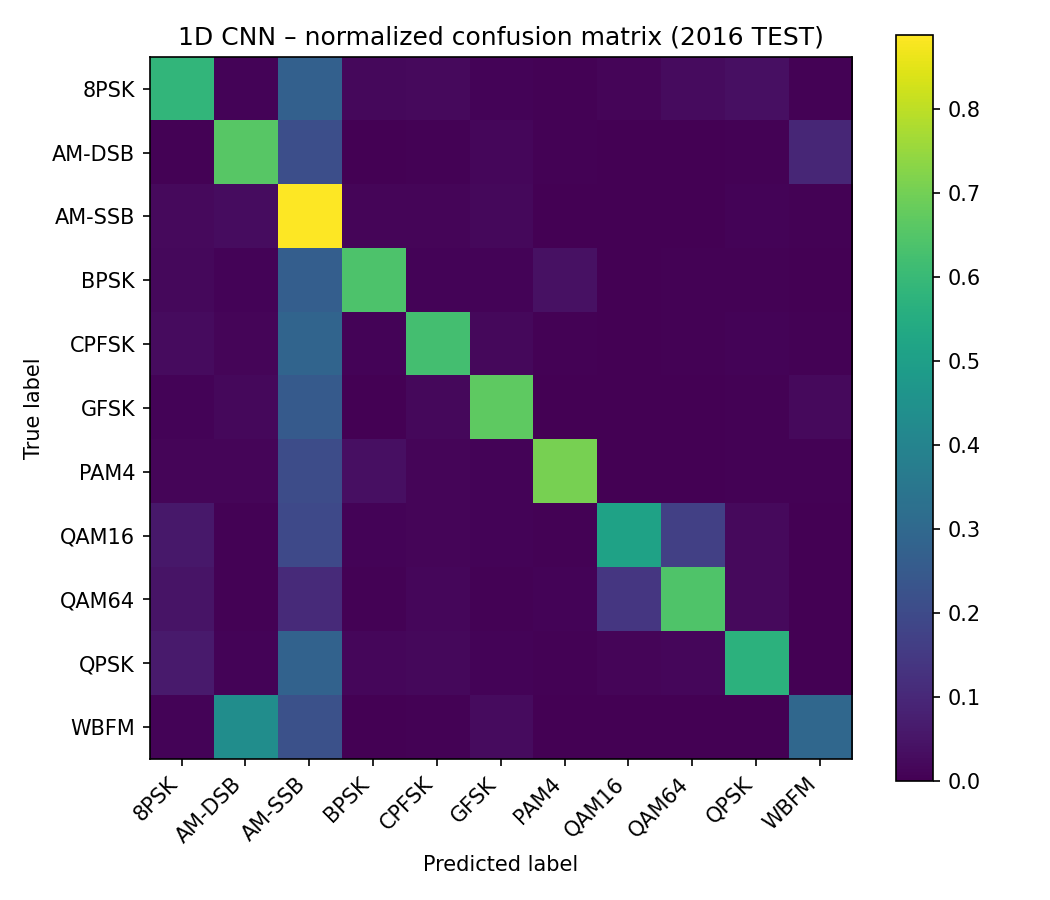

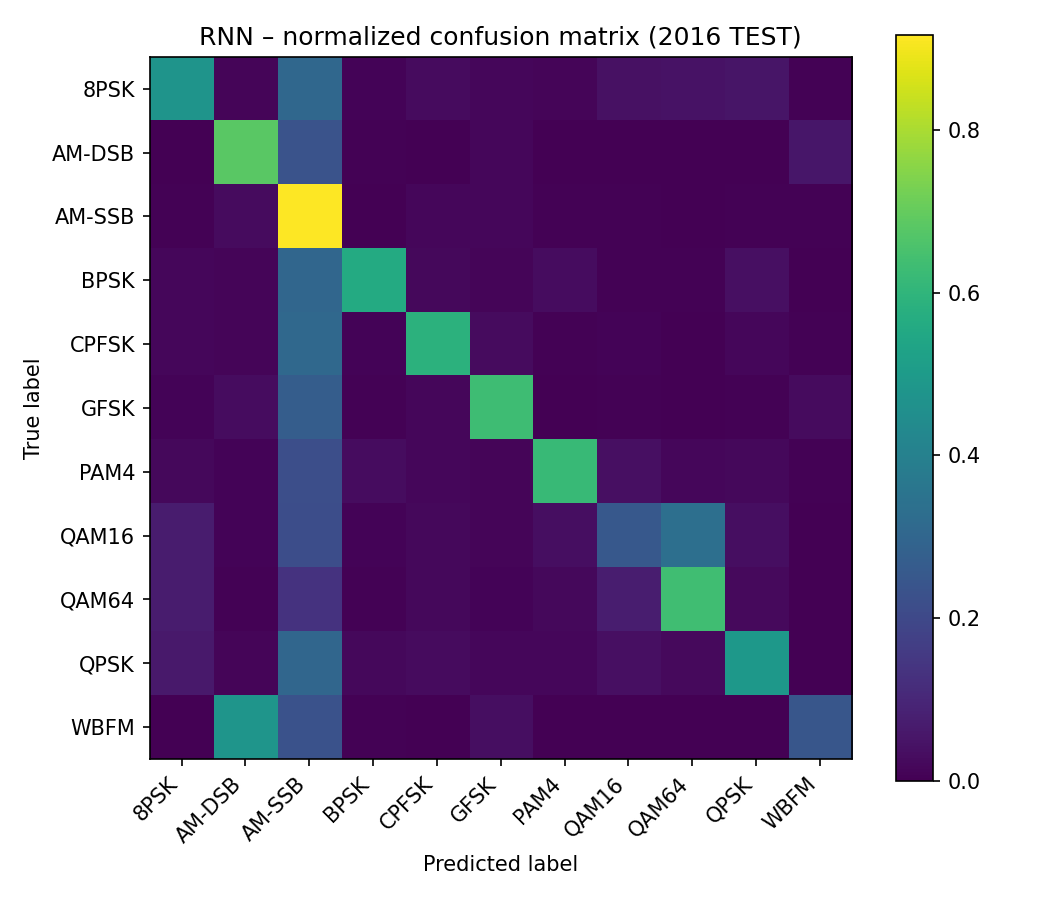

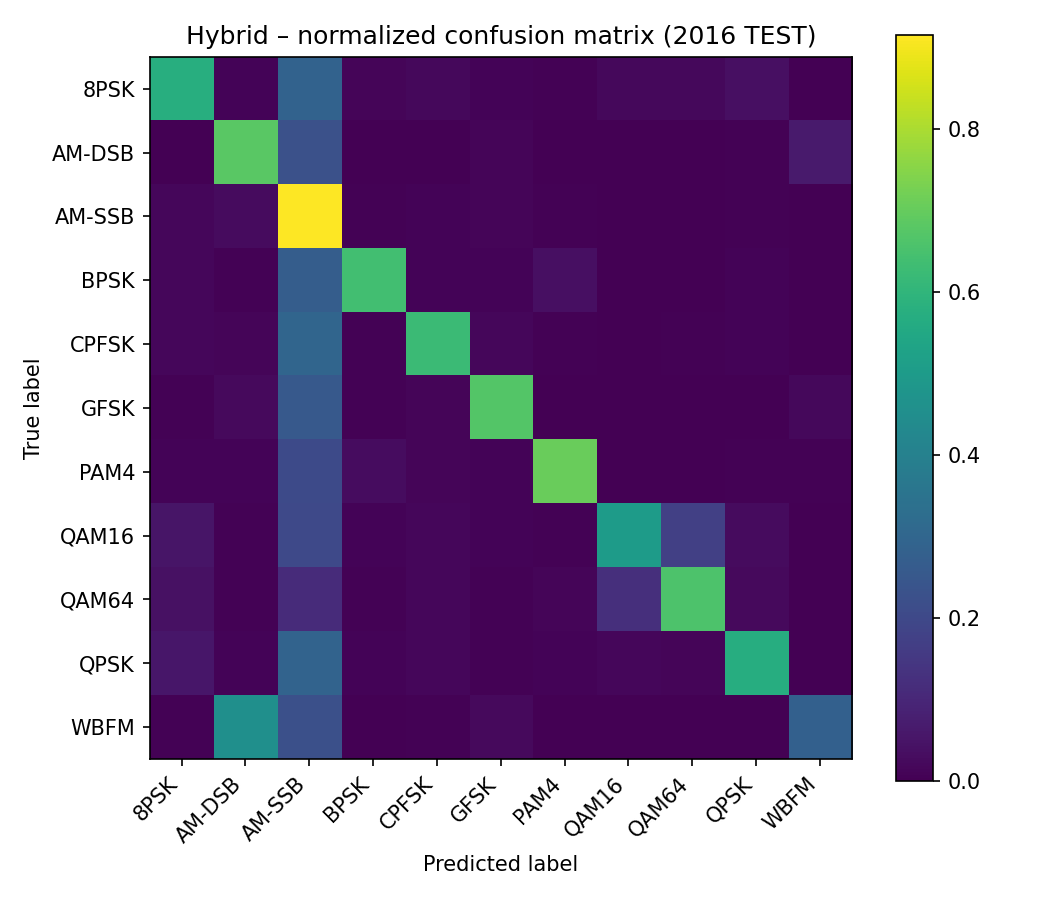

In [9]:
display(Image(filename=str(FINAL_CHARTS_DIR / "cm_cnn.png")))
display(Image(filename=str(FINAL_CHARTS_DIR / "cm_rnn.png")))
display(Image(filename=str(FINAL_CHARTS_DIR / "cm_hybrid.png")))


---

## 4  Takeaways

- Traditional models (especially **SVM / RF**) remain **strong baselines** for
  AMC on flattened I/Q and should not be ignored.
- The **1D CNN** and **RNN** learn richer representations directly from raw
  sequences and show better robustness across SNR, especially in mid/high SNR.
- The **Hybrid CNN+RNN** ensemble provides a simple, modular way to push
  performance further by combining:
  - spatial/feature extraction from the CNN, and
  - temporal modeling from the RNN.
- In a resource-constrained setting, a single CNN or even a tuned SVM/RF
  may be a good trade-off; where compute allows, the Hybrid is the most
  accurate and robust option among the models studied here.



### References

- T. O’Shea and J. Hoydis, “An Introduction to Deep Learning for the Physical Layer,”  
  *IEEE Transactions on Cognitive Communications and Networking*, 2017.  
  https://arxiv.org/abs/1702.00832

- T. O’Shea, J. Corgan, and T. Clancy, “Convolutional Radio Modulation Recognition Networks,” 2016.  
  https://arxiv.org/abs/1602.04105

- Ziqi Ke and Haris Vikalo, “Real-Time Radio Technology and Modulation Classification via an LSTM Auto-Encoder,”  
  The University of Texas at Austin, 2020.  
  https://arxiv.org/pdf/2011.08295

- Tong He, Zhi Zhang, Hang Zhang, Zhongyue Zhang, Junyuan Xie, and Mu Li,  
  “Bag of Tricks for Image Classification with Convolutional Neural Networks,”  
  *IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR) Workshops*, 2019.  
  https://arxiv.org/abs/1812.01187


- Zheng Li, Ying Huang, Defang Chen, Tianren Luo, Ning Cai, and Zhigeng Pan,  
  “Online Knowledge Distillation via Multi-branch Diversity Enhancement,”  
  *Asian Conference on Computer Vision (ACCV)*, 2020.  
  https://openaccess.thecvf.com/content/ACCV2020/papers/Li_Online_Knowledge_Distillation_via_Multi-branch_Diversity_Enhancement_ACCV_2020_paper.pdf
